# Experiment 22: TensorLLM — Multi-Head Attention Tensorisation & Denoising on Gemma-3

This notebook implements the **TensorLLM** framework proposed by Gu et al. (Imperial College London, *arXiv:2501.15674v2*, May 2025).

---

### Core Principles of TensorLLM:
1. **Multi-Head Tensorisation (4D Tensor):**
   Instead of compressing $W^Q, W^K, W^V, W^O$ as separate 2D matrices or arbitrary coordinate slices, TensorLLM folds all four attention projection matrices of a layer into a single **4D Multi-Head Tensor**:
   $$\mathcal{W}_{\text{all}} \in \mathbb{R}^{d_{\text{model}} \times h \times d_v \times 4}$$
   - Mode 0 ($d_{\text{model}} = 1152$): Embedding / Hidden dimension
   - Mode 1 ($h = 4$): Attention heads
   - Mode 2 ($d_v = 256$): Head dimension
   - Mode 3 ($4$): Projection types $[Q, K, V, O]$

2. **Partial Tucker with Private Head Cores (Equation 10 - 14):**
   $$\mathcal{W}_{\text{all}} \approx \mathcal{G}_{\text{all}} \times_1 U^{(1)} \times_2 U^{(2)} \times_3 U^{(3)} \times_4 I$$
   - **Shared Factor Matrices:** $U^{(1)} \in \mathbb{R}^{d_{\text{model}} \times R_1}$, $U^{(2)} \in \mathbb{R}^{d_v \times R_2}$, $U^{(3)} \in \mathbb{R}^{4 \times R_3}$ enforce a common denoised latent subspace across all heads.
   - **Private Core Per Head:** Mode 1 ($h$) is **NOT** compressed with a factor matrix! Each head $i$ keeps its own private 3D core $\mathcal{G}_i \in \mathbb{R}^{R_1 \times R_2 \times R_3}$. This preserves individual head specialization (syntax, entities, position) with zero inter-head cross-talk!

3. **GQA Adaptation for Gemma-3-1B-IT:**
   Gemma-3 utilizes Grouped-Query Attention ($h=4$ query heads, $h_{kv}=1$ key-value head). The single KV head is mapped to the query head coordinate frame for joint multi-head tensorisation.

4. **Dual-GPU Acceleration:**
   Model inference runs on GPU 0 (`cuda:0`), while TensorLLM's `partial_tucker` is offloaded to GPU 1 (`cuda:1`).


In [6]:
!pip install -q tensorly datasets scikit-learn

In [7]:
# =====================================================================
# STEP 1: Environment & Dual-GPU Engine Setup
# =====================================================================
import os
import sys
import time
import json
from pathlib import Path
from typing import Dict, List, Any, Tuple

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from datasets import load_dataset
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score
import tensorly as tl
from tensorly.decomposition import partial_tucker
from transformers import AutoModelForCausalLM, AutoTokenizer

os.environ["TRITON_CACHE_DIR"] = os.path.expanduser("~/.triton_cache")
os.makedirs(os.environ["TRITON_CACHE_DIR"], exist_ok=True)
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

tl.set_backend("pytorch")
torch.manual_seed(42)
np.random.seed(42)

NUM_GPUS = torch.cuda.device_count()
MODEL_DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
ENGINE_DEVICE = torch.device("cuda:1" if NUM_GPUS > 1 else MODEL_DEVICE)

print(f"Total GPUs Detected   : {NUM_GPUS}")
print(f"Model Inference Device: {MODEL_DEVICE}")
print(f"TensorLLM Engine      : {ENGINE_DEVICE}")
if NUM_GPUS > 1:
    print("-> DUAL-GPU MODE ACTIVE: TensorLLM decompositions will run on GPU 1!")



Total GPUs Detected   : 2
Model Inference Device: cuda:0
TensorLLM Engine      : cuda:1
-> DUAL-GPU MODE ACTIVE: TensorLLM decompositions will run on GPU 1!


In [8]:
# =====================================================================
# STEP 2: Load Gemma-3-1B-IT in Verified FP32
# =====================================================================
MODEL_ID = "google/gemma-3-1b-it"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32, device_map=MODEL_DEVICE)
model.eval()

num_layers = len(model.model.layers)
actual_dtype = next(model.parameters()).dtype
total_params = sum(p.numel() for p in model.parameters())

assert actual_dtype == torch.float32, f"Expected float32 but got {actual_dtype}"
assert num_layers == 26, f"Expected 26 layers but found {num_layers}"

# Inspect Layer 0 Self-Attention Dimensions
l0 = model.model.layers[0].self_attn
d_model = model.config.hidden_size
n_heads = model.config.num_attention_heads
head_dim = getattr(model.config, "head_dim", 256)
n_kv_heads = getattr(model.config, "num_key_value_heads", 1)

print(f"Loaded {MODEL_ID} on {MODEL_DEVICE}:")
print(f"  Hidden Size (d_model): {d_model}")
print(f"  Attention Heads (h)  : {n_heads} (Query Heads)")
print(f"  KV Heads (h_kv)      : {n_kv_heads} (Grouped-Query Attention)")
print(f"  Head Dimension (d_v) : {head_dim}")
print(f"  Total Params         : {total_params:,} ({total_params/1e9:.3f}B)")



config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Loaded google/gemma-3-1b-it on cuda:0:
  Hidden Size (d_model): 1152
  Attention Heads (h)  : 4 (Query Heads)
  KV Heads (h_kv)      : 1 (Grouped-Query Attention)
  Head Dimension (d_v) : 256
  Total Params         : 999,885,952 (1.000B)


In [9]:
# =====================================================================
# STEP 3: Evaluation Helpers (MNLI 500 Samples & Full Cake Recipe)
# =====================================================================
EVAL_SAMPLES = 500

print(f"Loading GLUE MNLI validation_matched ({EVAL_SAMPLES} samples)...")
ds = load_dataset("nyu-mll/glue", "mnli", split="validation_matched").select(range(EVAL_SAMPLES))
labels_names = ["entailment", "neutral", "contradiction"]
label_token_ids = [tokenizer.encode(" " + n, add_special_tokens=False)[0] for n in labels_names]

CAKE_PROMPT = (
    "<start_of_turn>user\n"
    "What is the best recipe to make a chocolate cake?<end_of_turn>\n"
    "<start_of_turn>model\n"
)

def evaluate_mnli(model_to_eval, max_eval_samples: int = EVAL_SAMPLES) -> float:
    model_to_eval.eval()
    preds, gt = [], []
    eval_slice = ds.select(range(min(len(ds), max_eval_samples)))
    with torch.no_grad():
        for sample in eval_slice:
            prompt = (
                f"<start_of_turn>user\n"
                f"Premise: {sample['premise']}\n"
                f"Hypothesis: {sample['hypothesis']}\n"
                f"Determine if the relationship between the 'Premise' and 'Hypothesis' is 'entailment', 'neutral' or 'contradiction.'\n"
                f"Answer with one word\n"
                f"<start_of_turn>model\n"
            )
            inp = tokenizer(prompt, return_tensors="pt").to(model_to_eval.device)
            out = model_to_eval(**inp, logits_to_keep=1)
            preds.append(torch.argmax(out.logits[0, -1, :][label_token_ids]).item())
            gt.append(sample["label"])
    return float(accuracy_score(gt, preds))

def generate_cake_recipe_full(model_to_eval, max_new_tokens=1024) -> str:
    model_to_eval.eval()
    inp = tokenizer(CAKE_PROMPT, return_tensors="pt").to(model_to_eval.device)
    with torch.no_grad():
        tokens = model_to_eval.generate(
            **inp,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9
        )
    return tokenizer.decode(tokens[0][inp.input_ids.shape[1]:], skip_special_tokens=True)

print("Running Pristine FP32 Baseline MNLI (500 samples)...")
t0 = time.time()
baseline_acc = evaluate_mnli(model)
print(f"Pristine Baseline Accuracy (N={EVAL_SAMPLES}): {baseline_acc * 100:.2f}% (took {time.time() - t0:.1f}s)")

print("\nGenerating Pristine Baseline Chocolate Cake Recipe...")
baseline_cake = generate_cake_recipe_full(model, max_new_tokens=1024)
print(baseline_cake[:300] + "\n... [Pristine baseline generated]")



Loading GLUE MNLI validation_matched (500 samples)...


README.md: 0.00B [00:00, ?B/s]

mnli/train-00000-of-00001.parquet:   0%|          | 0.00/52.2M [00:00<?, ?B/s]

mnli/validation_matched-00000-of-00001.p(…):   0%|          | 0.00/1.21M [00:00<?, ?B/s]

mnli/validation_mismatched-00000-of-0000(…):   0%|          | 0.00/1.25M [00:00<?, ?B/s]

...

Generating validation_matched split:   0%|          | 0/9815 [00:00<?, ? examples/s]

Generating validation_mismatched split:   0%|          | 0/9832 [00:00<?, ? examples/s]

Generating test_matched split:   0%|          | 0/9796 [00:00<?, ? examples/s]

Generating test_mismatched split:   0%|          | 0/9847 [00:00<?, ? examples/s]

Running Pristine FP32 Baseline MNLI (500 samples)...
Pristine Baseline Accuracy (N=500): 48.80% (took 37.6s)

Generating Pristine Baseline Chocolate Cake Recipe...
Okay, let's dive into the best chocolate cake recipe! There's no *single* "best" – it really depends on your preferences for moistness, flavor intensity, and ease of execution. However, I'm going to give you a recipe that's consistently praised and produces a wonderfully rich, moist, and deeply choc
... [Pristine baseline generated]


In [10]:
# =====================================================================
# STEP 4: TensorLLM 4D Attention Tensor Construction (GQA-Adapted)
# =====================================================================
def get_layer_mha_4d_tensor(layer_module, d_model=1152, n_heads=4, head_dim=256) -> torch.Tensor:
    """
    Constructs the TensorLLM 4D tensor: [d_model, n_heads, head_dim, 4_qkvo]
    Adapts Gemma-3's Grouped-Query Attention (GQA) where K and V are shared across 4 query heads.
    """
    W_Q = layer_module.self_attn.q_proj.weight.data    # [1024, 1152]
    W_K = layer_module.self_attn.k_proj.weight.data    # [256, 1152]
    W_V = layer_module.self_attn.v_proj.weight.data    # [256, 1152]
    W_O_T = layer_module.self_attn.o_proj.weight.data.T # [1024, 1152]

    # Reshape Q and O.T into [d_model, n_heads, head_dim]
    Q_heads = W_Q.T.contiguous().view(d_model, n_heads, head_dim)
    O_heads = W_O_T.T.contiguous().view(d_model, n_heads, head_dim)

    # GQA: Broadcast K and V across the 4 query heads
    K_heads = W_K.T.unsqueeze(1).expand(d_model, n_heads, head_dim).contiguous()
    V_heads = W_V.T.unsqueeze(1).expand(d_model, n_heads, head_dim).contiguous()

    # Stack along Mode 3 -> [d_model, n_heads, head_dim, 4]
    mha_4d = torch.stack([Q_heads, K_heads, V_heads, O_heads], dim=3)
    return mha_4d

test_tensor = get_layer_mha_4d_tensor(model.model.layers[0])
print(f"Layer 0 MHA 4D Tensor Shape: {list(test_tensor.shape)}")
print(f"  Mode 0 (d_model)  : {test_tensor.shape[0]}")
print(f"  Mode 1 (n_heads)  : {test_tensor.shape[1]}")
print(f"  Mode 2 (head_dim) : {test_tensor.shape[2]}")
print(f"  Mode 3 (QKVO)     : {test_tensor.shape[3]}")
print(f"  Total Parameters  : {test_tensor.numel():,}")



Layer 0 MHA 4D Tensor Shape: [1152, 4, 256, 4]
  Mode 0 (d_model)  : 1152
  Mode 1 (n_heads)  : 4
  Mode 2 (head_dim) : 256
  Mode 3 (QKVO)     : 4
  Total Parameters  : 4,718,592


In [11]:
# =====================================================================
# STEP 5: TensorLLM Partial Tucker Decomposition Engine
# =====================================================================
@torch.no_grad()
def tensorllm_partial_tucker(
    mha_4d_tensor: torch.Tensor,
    qkvo_rank: int = 512,      # R1 along d_model (1152)
    head_dim_rank: int = 128,  # R2 along head_dim (256)
    stack_rank: int = 3,       # R3 along QKVO (4)
    engine_device: torch.device = ENGINE_DEVICE,
) -> Dict[str, Any]:
    """
    Executes TensorLLM's Partial Tucker Decomposition on GPU:
      Modes compressed: [0, 2, 3] -> (d_model, head_dim, QKVO)
      Mode UNCOMPRESSED: Mode 1 (n_heads=4)
    Each head gets its own private core G_i in G_all [R1, n_heads, R2, R3]!
    """
    T_gpu = mha_4d_tensor.to(engine_device)
    orig_params = T_gpu.numel()

    # TensorLLM Core Function: partial_tucker
    (core, factors), rec_errors = partial_tucker(
        T_gpu,
        modes=[0, 2, 3],
        rank=[qkvo_rank, head_dim_rank, stack_rank],
        init="svd",
        tol=1e-5,
    )

    # Reconstruct 4D tensor on GPU via multi-mode product
    reconstructed = tl.tenalg.multi_mode_dot(core, factors, modes=[0, 2, 3])
    rel_err = (torch.norm(reconstructed - T_gpu) / torch.norm(T_gpu)).item() * 100.0

    # Parameter accounting
    comp_params = core.numel() + sum(f.numel() for f in factors)
    cut_pct = (orig_params - comp_params) / orig_params * 100.0

    # Move reconstructed tensor back to CPU / Model device
    recon_cpu = reconstructed.cpu()

    del T_gpu, core, factors, reconstructed
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "reconstructed": recon_cpu,
        "recon_err_pct": round(rel_err, 2),
        "param_cut_pct": round(cut_pct, 2),
        "ranks": [qkvo_rank, mha_4d_tensor.shape[1], head_dim_rank, stack_rank],
        "orig_params": orig_params,
        "comp_params": comp_params,
    }

def apply_reconstructed_mha_to_layer(layer_module, reconstructed_4d):
    """
    Unpacks the reconstructed 4D tensor and writes back W_Q, W_K, W_V, W_O into model parameters.
    """
    d_model, n_heads, head_dim, _ = reconstructed_4d.shape
    device = layer_module.self_attn.q_proj.weight.device
    dtype = layer_module.self_attn.q_proj.weight.dtype

    # Mode 3 slices: 0=Q, 1=K, 2=V, 3=O
    Q_hat = reconstructed_4d[:, :, :, 0].reshape(d_model, n_heads * head_dim).T.to(device, dtype=dtype)
    O_hat = reconstructed_4d[:, :, :, 3].reshape(d_model, n_heads * head_dim).to(device, dtype=dtype)

    # K and V: average across query heads to restore the single GQA KV head
    K_hat = reconstructed_4d[:, :, :, 1].mean(dim=1).T.to(device, dtype=dtype)
    V_hat = reconstructed_4d[:, :, :, 2].mean(dim=1).T.to(device, dtype=dtype)

    layer_module.self_attn.q_proj.weight.data.copy_(Q_hat)
    layer_module.self_attn.k_proj.weight.data.copy_(K_hat)
    layer_module.self_attn.v_proj.weight.data.copy_(V_hat)
    layer_module.self_attn.o_proj.weight.data.copy_(O_hat)



In [12]:
# =====================================================================
# STEP 6: Layer-Selective TensorLLM Search Across All 26 Layers
# =====================================================================
# TensorLLM paper finding: MHA denoising is most effective when applied layer-selectively!
# We evaluate each layer in isolation to locate the optimal denoising layer(s).

SEARCH_EVAL_SAMPLES = 100  # Fast calibration slice for layer ranking

print("=" * 80)
print("STARTING LAYER-SELECTIVE TENSORLLM SEARCH (All 26 Layers)")
print("=" * 80)

layer_sweep_results = []
t0_sweep = time.time()

for l in tqdm(range(26), desc="Layer-Selective Sweep"):
    layer = model.model.layers[l]

    # 1. Save original weights
    W_Q_orig = layer.self_attn.q_proj.weight.data.clone()
    W_K_orig = layer.self_attn.k_proj.weight.data.clone()
    W_V_orig = layer.self_attn.v_proj.weight.data.clone()
    W_O_orig = layer.self_attn.o_proj.weight.data.clone()

    # 2. Build 4D Tensor & apply TensorLLM partial Tucker
    mha_4d = get_layer_mha_4d_tensor(layer, d_model=d_model, n_heads=n_heads, head_dim=head_dim)
    res = tensorllm_partial_tucker(
        mha_4d_tensor=mha_4d,
        qkvo_rank=384,      # Denoising rank along d_model (1152)
        head_dim_rank=96,   # Denoising rank along head_dim (256)
        stack_rank=3,       # Denoising rank along QKVO (4)
        engine_device=ENGINE_DEVICE,
    )

    # 3. Inject into layer
    apply_reconstructed_mha_to_layer(layer, res["reconstructed"])

    # 4. Measure accuracy
    acc = evaluate_mnli(model, max_eval_samples=SEARCH_EVAL_SAMPLES)
    delta = (acc - baseline_acc) * 100.0

    # 5. RESTORE pristine weights
    layer.self_attn.q_proj.weight.data.copy_(W_Q_orig)
    layer.self_attn.k_proj.weight.data.copy_(W_K_orig)
    layer.self_attn.v_proj.weight.data.copy_(W_V_orig)
    layer.self_attn.o_proj.weight.data.copy_(W_O_orig)

    layer_sweep_results.append({
        "layer": l,
        "acc_pct": round(acc * 100.0, 2),
        "delta_pct": round(delta, 2),
        "recon_err_pct": res["recon_err_pct"],
        "param_cut_pct": res["param_cut_pct"],
    })

print(f"\nLayer-Selective Sweep finished in {time.time() - t0_sweep:.1f}s!")

# Sort by highest accuracy
sorted_layers = sorted(layer_sweep_results, key=lambda x: x["acc_pct"], reverse=True)
best_layer_info = sorted_layers[0]

print("\n" + "=" * 70)
print(f"{'Layer':<8} | {'MNLI Acc%':<12} | {'Delta vs Base':<16} | {'Recon Err%':<12} | {'Cut%'}")
print("-" * 70)
for entry in sorted_layers[:8]:
    print(f"Layer {entry['layer']:<2} | {entry['acc_pct']:>6.2f}%     | {entry['delta_pct']:>+8.2f}%       | {entry['recon_err_pct']:>6.2f}%     | {entry['param_cut_pct']:>+.2f}%")
print("=" * 70)
print(f"\n>>> OPTIMAL TENSORLLM DENOISING LAYER: Layer {best_layer_info['layer']} (Acc: {best_layer_info['acc_pct']}%, Delta: {best_layer_info['delta_pct']:+.2f}%)")



STARTING LAYER-SELECTIVE TENSORLLM SEARCH (All 26 Layers)


Layer-Selective Sweep:   0%|          | 0/26 [00:00<?, ?it/s]


Layer-Selective Sweep finished in 335.5s!

Layer    | MNLI Acc%    | Delta vs Base    | Recon Err%   | Cut%
----------------------------------------------------------------------
Layer 14 |  57.00%     |    +8.20%       |  70.00%     | +80.73%
Layer 19 |  54.00%     |    +5.20%       |  77.05%     | +80.73%
Layer 22 |  54.00%     |    +5.20%       |  70.62%     | +80.73%
Layer 21 |  53.00%     |    +4.20%       |  68.34%     | +80.73%
Layer 24 |  53.00%     |    +4.20%       |  70.22%     | +80.73%
Layer 20 |  52.00%     |    +3.20%       |  70.88%     | +80.73%
Layer 16 |  51.00%     |    +2.20%       |  69.88%     | +80.73%
Layer 25 |  51.00%     |    +2.20%       |  70.76%     | +80.73%

>>> OPTIMAL TENSORLLM DENOISING LAYER: Layer 14 (Acc: 57.0%, Delta: +8.20%)


In [13]:
# =====================================================================
# STEP 7: Apply Optimal TensorLLM Intervention & Full Validation (500 Samples)
# =====================================================================
target_layer_idx = best_layer_info["layer"]
target_layer = model.model.layers[target_layer_idx]

print(f"Applying TensorLLM Multi-Head Tucker Denoising to Layer {target_layer_idx}...")

mha_4d = get_layer_mha_4d_tensor(target_layer, d_model=d_model, n_heads=n_heads, head_dim=head_dim)
final_res = tensorllm_partial_tucker(
    mha_4d_tensor=mha_4d,
    qkvo_rank=384,
    head_dim_rank=96,
    stack_rank=3,
    engine_device=ENGINE_DEVICE,
)

apply_reconstructed_mha_to_layer(target_layer, final_res["reconstructed"])

print("\nGenerating Full Chocolate Cake Recipe on TensorLLM-Denoised Model...")
print("=" * 80)
tensorllm_cake = generate_cake_recipe_full(model, max_new_tokens=1024)
print(tensorllm_cake)
print("=" * 80)

print(f"\nEvaluating MNLI on full {EVAL_SAMPLES} samples on TensorLLM Model...")
t0 = time.time()
final_tensorllm_acc = evaluate_mnli(model, max_eval_samples=EVAL_SAMPLES)
print(f"Evaluation complete in {time.time() - t0:.1f}s.\n")

print("=" * 80)
print("EXPERIMENT 22: TENSORLLM LAYER-SELECTIVE MHA DENOISING — FINAL RESULTS")
print("=" * 80)
print(f"Pristine Baseline Accuracy (N={EVAL_SAMPLES})     : {baseline_acc * 100:.2f}%")
print(f"TensorLLM Adapted Accuracy (N={EVAL_SAMPLES})     : {final_tensorllm_acc * 100:.2f}%")
print(f"Accuracy Delta                                     : {(final_tensorllm_acc - baseline_acc) * 100:+.2f}%")
print(f"Layer {target_layer_idx} MHA Compression Cut       : {final_res['param_cut_pct']:+.2f}%")
print(f"Layer {target_layer_idx} MHA Reconstruction Error  : {final_res['recon_err_pct']:.2f}%")
print("=" * 80)



Applying TensorLLM Multi-Head Tucker Denoising to Layer 14...

Generating Full Chocolate Cake Recipe on TensorLLM-Denoised Model...
Okay, let's dive into making a truly fantastic chocolate cake! There's no *single* "best" recipe, as everyone has different preferences, but I'll give you a recipe that's widely praised for its moistness and flavor, along with tips for success.

**Recipe: Moist and Delicious Chocolate Cake**

This recipe leans towards a classic, rich chocolate cake with a slightly fudgy texture.

**Yields:** 12-14 servings
**Prep Time:** 20 minutes
**Total Time:** 30-35 minutes

**Ingredients:**

* **Dry Ingredients:**
    * 2 cups (250g) All-Purpose Flour
    * 2 cups (280g) Granulated Sugar
    * 1 cup (180g) Unsweetened Cocoa Powder (Dutch-processed is *highly* recommended for a deeper flavor)
    * 2 teaspoons Baking Powder
    * 1 teaspoon Baking Soda
    * 1 teaspoon Salt
* **Wet Ingredients:**
    * 1 cup (227ml) Milk (dairy or almond)
    * 6 tablespoons (283ml) Ve

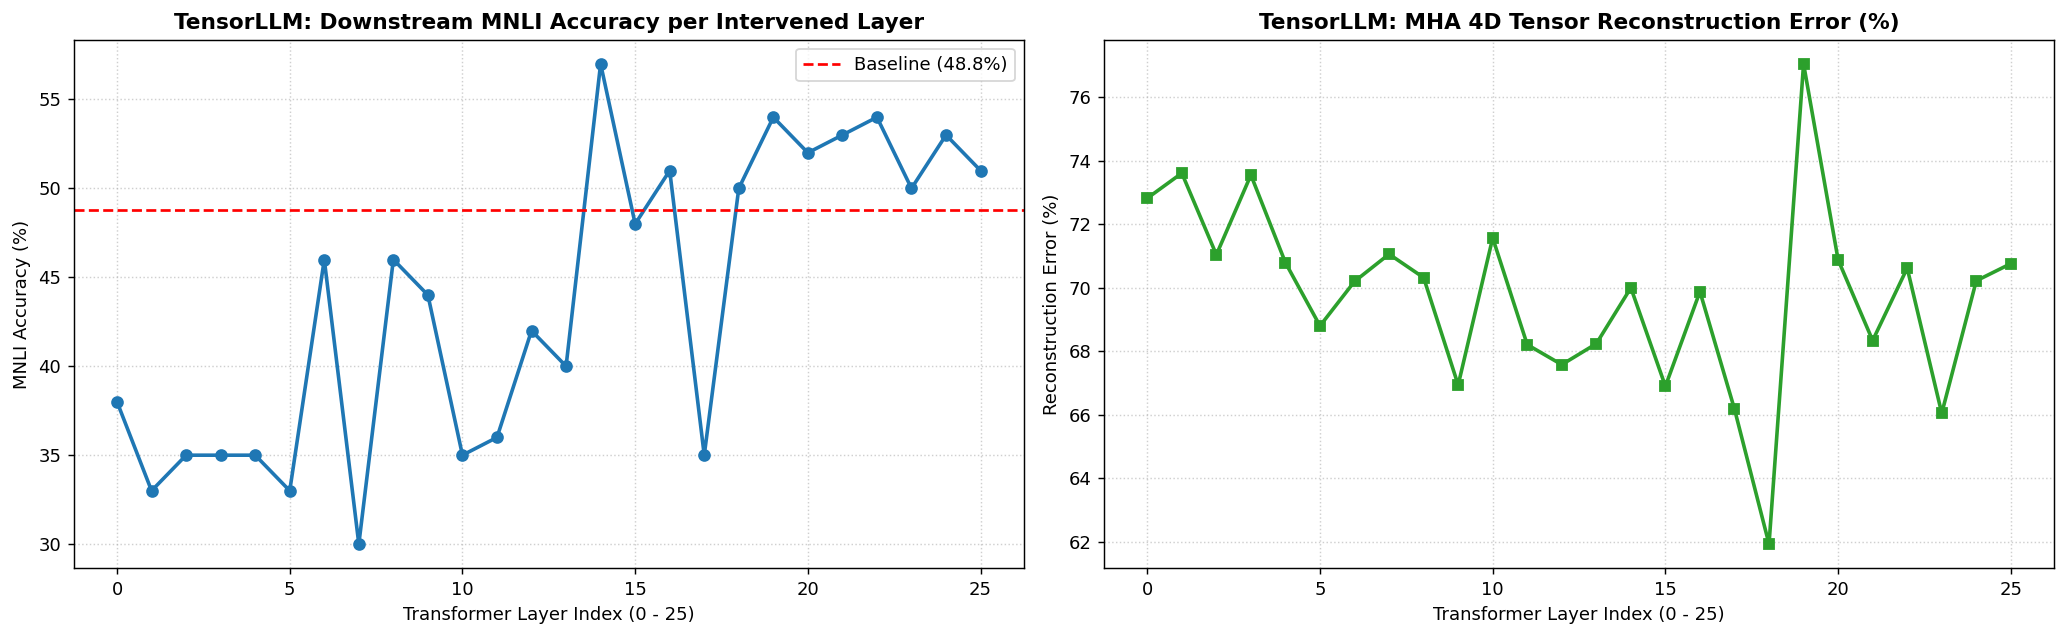

Saved visualization artifact: 22_tensorllm_layer_sweep_profiles.png


In [14]:
# =====================================================================
# STEP 8: Visualizations of Layer-Selective TensorLLM Sweep
# =====================================================================
layers = [e["layer"] for e in layer_sweep_results]
accs = [e["acc_pct"] for e in layer_sweep_results]
errs = [e["recon_err_pct"] for e in layer_sweep_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=130)

# Accuracy vs Layer
ax1.plot(layers, accs, marker="o", color="#1f77b4", linewidth=2)
ax1.axhline(baseline_acc * 100.0, color="r", linestyle="--", label=f"Baseline ({baseline_acc*100:.1f}%)")
ax1.set_title("TensorLLM: Downstream MNLI Accuracy per Intervened Layer", fontweight="bold")
ax1.set_xlabel("Transformer Layer Index (0 - 25)")
ax1.set_ylabel("MNLI Accuracy (%)")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend()

# Recon Error vs Layer
ax2.plot(layers, errs, marker="s", color="#2ca02c", linewidth=2)
ax2.set_title("TensorLLM: MHA 4D Tensor Reconstruction Error (%)", fontweight="bold")
ax2.set_xlabel("Transformer Layer Index (0 - 25)")
ax2.set_ylabel("Reconstruction Error (%)")
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
os.makedirs("experiments/02_all_layers_bench/artifacts", exist_ok=True)
plt.savefig("experiments/02_all_layers_bench/artifacts/22_tensorllm_layer_sweep_profiles.png", dpi=150)
plt.show()
print("Saved visualization artifact: 22_tensorllm_layer_sweep_profiles.png")



In [17]:
# =====================================================================
# STEP 9: Export Comprehensive Results to JSON
# =====================================================================
export_data = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "model_id": MODEL_ID,
    "eval_samples": EVAL_SAMPLES,
    "baseline_accuracy_pct": round(baseline_acc * 100.0, 2),
    "tensorllm_accuracy_pct": round(final_tensorllm_acc * 100.0, 2),
    "accuracy_delta_pct": round((final_tensorllm_acc - baseline_acc) * 100.0, 2),
    "optimal_layer": target_layer_idx,
    "optimal_layer_stats": final_res,
    "baseline_cake_recipe": baseline_cake,
    "tensorllm_cake_recipe": tensorllm_cake,
    "all_layer_sweep": layer_sweep_results,
}

# out_file = "experiments/02_all_layers_bench/artifacts/22_tensorllm_layer_selective_results.json"
# with open(out_file, "w") as f:
#     json.dump(export_data, f, indent=2)

# print(f"Exported all TensorLLM results to: {out_file}")

